## Kurulum

In [1]:
# check assigned GPU, T4 expected
# atanan GPU kontrolu, T4 bekleniyor
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader


Tesla T4, 15360 MiB


In [2]:
# install ultralytics
# ultralytics kurulumu
!pip install -q ultralytics openpyxl
import ultralytics
ultralytics.checks()


Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.7/235.7 GB disk)


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
from pathlib import Path
import shutil

# same cropped dataset used for YOLO11 (Deney 2a/2b) -- no changes needed
# YOLO11 icin kullanilan ayni kirpilmis veri seti (Deney 2a/2b) -- degisiklik yok
DATASET_ROOT = '/content/drive/MyDrive/Kitle-Vindr-Cropped'

# Deney 2f: YOLO26s optimizer test. Deney 2c (AdamW, imgsz=1024) capped at
# mAP@50 0.6494; Deney 2d (imgsz=1280) made it worse (0.6220), ruling out
# resolution as the lever. Meanwhile Deney 2e proved for YOLO11s that SGD
# (lr0=0.001, same scale as AdamW -- lr0=0.01 destabilized training) beats
# AdamW by a wide margin (0.7561 vs 0.6901). Testing the same fix here.
# Separate MODEL_NAME so Deney 2c/2d's Drive results are not touched.
# Deney 2f: YOLO26s optimizer denemesi. Deney 2c (AdamW, imgsz=1024)
# mAP@50 0.6494'te tavan yapti; Deney 2d (imgsz=1280) daha kotu sonuc verdi
# (0.6220), cozunurluk levar olarak elendi. Bu arada Deney 2e, YOLO11s icin
# SGD'nin (lr0=0.001, AdamW ile ayni olcek -- lr0=0.01 egitimi
# kararsizlastirmisti) AdamW'yi acik farkla gectigini kanitladi (0.7561 vs
# 0.6901). Ayni duzeltme burada da deneniyor. Ayri MODEL_NAME kullanildi
# ki Deney 2c/2d'nin Drive'daki sonuclari bozulmasin.
MODEL_NAME = 'yolo26s_cropped_sgd'

# Drive is the durable store (checkpoints survive a disconnect); local disk
# is a fast mirror of every output. Same dual-save strategy as YOLO11.
# Drive kalici depo (checkpoint'ler koparsa kaybolmaz); yerel disk her
# ciktinin hizli bir aynasidir. YOLO11 ile ayni ikili kayit stratejisi.
DRIVE_DIR = f'/content/drive/MyDrive/mass_detection/{MODEL_NAME}'
LOCAL_DIR = f'/content/outputs/{MODEL_NAME}'
Path(DRIVE_DIR).mkdir(parents=True, exist_ok=True)
Path(LOCAL_DIR).mkdir(parents=True, exist_ok=True)

EXCEL_LOG = f'{DRIVE_DIR}/{MODEL_NAME}_log.xlsx'
DATA_YAML = f'{DRIVE_DIR}/mass_data.yaml'

assert Path(DATASET_ROOT).is_dir(), f'Yol yok: {DATASET_ROOT}'
print('Dataset (kirpilmis):', DATASET_ROOT)
print('Drive cikti (kalici):', DRIVE_DIR)
print('Yerel cikti (ayna):', LOCAL_DIR)


def mirror_to_local(drive_path):
    # copy a Drive output file to the local mirror, same filename
    # Drive'daki bir cikti dosyasini ayni adla yerel aynaya kopyala
    dst = Path(LOCAL_DIR) / Path(drive_path).name
    shutil.copy2(drive_path, dst)
    return str(dst)


Dataset (kirpilmis): /content/drive/MyDrive/Kitle-Vindr-Cropped
Drive cikti (kalici): /content/drive/MyDrive/mass_detection/yolo26s_cropped_sgd
Yerel cikti (ayna): /content/outputs/yolo26s_cropped_sgd


In [5]:
import yaml

# single class mass detection config
# tek sinif kutle tespiti ayari
data_cfg = {
    'path': DATASET_ROOT,
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': 1,
    'names': ['mass'],
}
with open(DATA_YAML, 'w') as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False)
mirror_to_local(DATA_YAML)
print('data.yaml yazildi:', DATA_YAML)


data.yaml yazildi: /content/drive/MyDrive/mass_detection/yolo26s_cropped_sgd/mass_data.yaml


## Veri Dogrulama

Kirpilmis veri (`Kitle-Vindr-Cropped`) YOLO11 denemelerinde (Deney 2a/2b)
zaten tam dogrulanmisti (train 3203, val 418, test 400 kutu) ve o zamandan
beri degismedi. Burada sadece hizli bir guvenlik kontrolu -- tam EDA/ornek
goruntu/augmentation onizlemesi tekrarlanmiyor (adil karsilastirma icin
veri ve augmentation politikasi PROJE_DOKUMANI.md bolum 6'da sabitlendi,
her modelde yeniden karar verilmiyor).

In [ ]:
import numpy as np

def split_stats(split):
    img_dir = Path(DATASET_ROOT) / split / 'images'
    lbl_dir = Path(DATASET_ROOT) / split / 'labels'
    imgs = sorted(img_dir.glob('*.png'))
    n_boxes = 0
    for ip in imgs:
        lp = lbl_dir / f'{ip.stem}.txt'
        if not lp.exists():
            continue
        for line in open(lp):
            if len(line.split()) >= 5:
                n_boxes += 1
    return len(imgs), n_boxes


expected = {'train': (2671, 3203), 'val': (333, 418), 'test': (336, 400)}
for split, (exp_img, exp_box) in expected.items():
    n_img, n_box = split_stats(split)
    ok = 'OK' if (n_img, n_box) == (exp_img, exp_box) else 'UYUSMUYOR!'
    print(f'{split:6s} goruntu={n_img} (beklenen {exp_img})  kutu={n_box} (beklenen {exp_box})  [{ok}]')


## Ortak Ayarlar

**Deney 2f.** İki önceki YOLO26 denemesi de AdamW ile tavan yaptı: Deney 2c
(imgsz=1024) 0.6494, Deney 2d (imgsz=1280) 0.6220 — çözünürlük artışı işe
yaramadı, sorun regularizasyon/çözünürlük değil. Bu arada Deney 2e, YOLO11s
için **`optimizer='SGD'`**'nin (uygun düşük `lr0` ile) AdamW'yi açık farkla
geçtiğini gösterdi (0.7561 vs 0.6901). Aynı değişiklik burada deneniyor:

- **`imgsz: 1280 -> 1024`** — Deney 2c'nin çözünürlüğüne dönülüyor (Deney 2d
  bunun daha iyi olduğunu kanıtlamıştı).
- **`optimizer='SGD'`, `lr0=0.001`** — YOLO11 Deney 2e'de `lr0=0.01` eğitimi
  kararsızlaştırmıştı (val loss fırladı, mAP epoch 2'de çöktü); doğrudan
  `lr0=0.001`'den (AdamW'nin ölçeği) başlanıyor, aynı hatayı tekrarlamadan.
- **`cos_lr=True`, `weight_decay=0.001`** — değişmedi.
- **`patience=5`** — Deney 2b'nin doğruladığı üzere yeterli.

`batch`, `epochs`, `seed` değişmiyor.

In [6]:
# shared config -- imgsz back to Deney 2c's 1024 (Deney 2d's 1280 was worse);
# patience unchanged at 5
# ortak ayar -- imgsz Deney 2c'nin 1024'une geri dondu (Deney 2d'nin 1280'i
# daha kotuydu); patience 5'te degismedi
COMMON = {
    'imgsz': 1024,   # was 1280 in Deney 2d, which underperformed Deney 2c
    'batch': 8,
    'epochs': 100,
    'patience': 5,
    'seed': 42,
}

# SGD instead of AdamW -- the variable under test in Deney 2f. lr0=0.001
# chosen directly (not 0.01) based on Deney 2e's finding that a higher SGD
# lr0 destabilizes training on this small dataset
# AdamW yerine SGD -- Deney 2f'nin test ettigi degisken. lr0=0.001 dogrudan
# secildi (0.01 degil), Deney 2e'nin bulgusuna dayanarak: bu kucuk veri
# setinde daha yuksek bir SGD lr0'i egitimi kararsizlastiriyor
OPTIM = {
    'optimizer': 'SGD',
    'lr0': 0.001,
    'cos_lr': True,
    'weight_decay': 0.001,
}

AUG = {
    'hsv_h': 0.0,
    'hsv_s': 0.0,
    'hsv_v': 0.2,
    'degrees': 5.0,
    'translate': 0.1,
    'scale': 0.3,
    'fliplr': 0.5,
    'flipud': 0.0,
    'mosaic': 0.3,
    'close_mosaic': 10,
    'mixup': 0.0,
    'erasing': 0.0,
}
print('Ortak ayar:', COMMON)
print('Optimizasyon ayari:', OPTIM)
print('Augmentation ayari:', AUG)


Ortak ayar: {'imgsz': 1024, 'batch': 8, 'epochs': 100, 'patience': 5, 'seed': 42}
Optimizasyon ayari: {'optimizer': 'SGD', 'lr0': 0.001, 'cos_lr': True, 'weight_decay': 0.001}
Augmentation ayari: {'hsv_h': 0.0, 'hsv_s': 0.0, 'hsv_v': 0.2, 'degrees': 5.0, 'translate': 0.1, 'scale': 0.3, 'fliplr': 0.5, 'flipud': 0.0, 'mosaic': 0.3, 'close_mosaic': 10, 'mixup': 0.0, 'erasing': 0.0}


## Egitim Altyapisi

Standart metrik semasi, canli Excel logu, ve egitim egrisi fonksiyonu; YOLO11
notebook'u ile birebir ayni (adil karsilastirma icin uc modelde de sabit
kalacak ortak modul).

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# standard metric schema, identical for all three models
# standart metrik semasi, uc model icin ayni
SCHEMA = ["epoch", "train_loss", "val_loss", "precision", "recall", "mAP50", "mAP50_95", "f1"]


def compute_f1(precision, recall):
    if precision is None or recall is None:
        return None
    denom = precision + recall
    if denom <= 0:
        return 0.0
    return 2 * precision * recall / denom


def append_epoch_row(excel_path, row, resume_epoch=None):
    if os.path.exists(excel_path):
        df = pd.read_excel(excel_path)
        if resume_epoch is not None:
            df = df[df["epoch"] < resume_epoch]
        rows = df.to_dict("records")
    else:
        rows = []
    clean = {k: row.get(k, None) for k in SCHEMA}
    rows.append(clean)
    pd.DataFrame(rows)[SCHEMA].to_excel(excel_path, index=False)
    return len(rows)


def plot_training_curves(excel_path, out_path, model_name):
    df = pd.read_excel(excel_path)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    ax.plot(df["epoch"], df["train_loss"], marker="o", markersize=3, label="Train")
    if df["val_loss"].notna().any():
        ax.plot(df["epoch"], df["val_loss"], marker="o", markersize=3, label="Val")
    ax.set_title("Loss"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    ax.plot(df["epoch"], df["mAP50"], marker="o", markersize=3, label="mAP@50")
    ax.plot(df["epoch"], df["mAP50_95"], marker="o", markersize=3, label="mAP@50-95")
    ax.set_title("mAP"); ax.set_xlabel("Epoch"); ax.set_ylabel("mAP")
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    ax.plot(df["epoch"], df["precision"], marker="o", markersize=3, color="tab:green", label="Precision")
    ax.set_title("Precision"); ax.set_xlabel("Epoch"); ax.set_ylabel("Precision")
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    ax.plot(df["epoch"], df["recall"], marker="o", markersize=3, color="tab:red", label="Recall")
    ax.set_title("Recall"); ax.set_xlabel("Epoch"); ax.set_ylabel("Recall")
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.suptitle(f"{model_name} Egitim Egrileri", fontsize=14)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    return out_path

print("Ortak modul hazir.")


Ortak modul hazir.


In [8]:
# callback maps Ultralytics metrics to standard schema and writes Excel live
# callback Ultralytics metriklerini standart semaya esler ve canli Excel yazar
def make_excel_callback(drive_excel_path):
    def on_fit_epoch_end(trainer):
        m = trainer.metrics
        p = m.get("metrics/precision(B)")
        r = m.get("metrics/recall(B)")
        map50 = m.get("metrics/mAP50(B)")
        map5095 = m.get("metrics/mAP50-95(B)")

        val_parts = [m.get("val/box_loss"), m.get("val/cls_loss"), m.get("val/dfl_loss")]
        val_loss = sum(val_parts) if all(v is not None for v in val_parts) else None

        train_loss = None
        if trainer.tloss is not None:
            tl = trainer.tloss
            train_loss = float(tl.sum()) if hasattr(tl, "sum") else float(tl)

        row = {
            "epoch": trainer.epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "precision": p,
            "recall": r,
            "mAP50": map50,
            "mAP50_95": map5095,
            "f1": compute_f1(p, r),
        }
        # Drive first (durable across a disconnect), then mirror locally
        # once Drive'a (koparsa kaybolmaz), sonra yerele aynala
        append_epoch_row(drive_excel_path, row)
        mirror_to_local(drive_excel_path)
    return on_fit_epoch_end

print("Callback hazir.")


Callback hazir.


## Egitim

In [9]:
from ultralytics import YOLO
import torch

# resume control: set True only if a run was interrupted and you want to continue
# resume kontrolu: sadece egitim kesildiyse ve devam etmek istiyorsan True yap
RESUME = False

WEIGHTS_DIR = Path(f'{DRIVE_DIR}/{MODEL_NAME}_mass/weights')
LAST_CKPT = WEIGHTS_DIR / 'last.pt'


def find_resumable_checkpoint():
    # last.pt gets its optimizer stripped (epoch=-1) once a run ends or
    # early-stops -- a stripped checkpoint can't be resumed, and forcing it
    # makes Ultralytics silently fall back to bare defaults (wrong
    # data/nc/settings) instead of erroring. Verify first; fall back to the
    # newest numbered save_period checkpoint (still has full optimizer
    # state) if last.pt isn't usable.
    # last.pt, bir calisma bitince/erken durunca optimizer'i siyrilip
    # epoch=-1 olur -- stripped checkpoint resume edilemez, zorlanirsa
    # Ultralytics hata vermek yerine sessizce ciplak varsayilanlara
    # (yanlis veri/nc/ayar) duser. Once dogrula; last.pt kullanilamazsa en
    # yeni numarali save_period checkpoint'ine (optimizer durumu tam) gec.
    if LAST_CKPT.exists():
        ckpt = torch.load(LAST_CKPT, map_location='cpu', weights_only=False)
        if ckpt.get('epoch', -1) >= 0:
            return LAST_CKPT
        print(f'{LAST_CKPT.name} stripped (epoch=-1, resume edilemez), numarali checkpoint araniyor...')
    numbered = sorted(WEIGHTS_DIR.glob('epoch*.pt'),
                       key=lambda p: int(p.stem.replace('epoch', '')))
    if not numbered:
        raise FileNotFoundError('Resume edilebilir checkpoint bulunamadi.')
    print('Kullanilacak checkpoint:', numbered[-1].name)
    return numbered[-1]


if RESUME:
    # continue from the newest resumable checkpoint, same run
    # en yeni resume edilebilir checkpoint'ten devam, ayni run
    resume_ckpt = find_resumable_checkpoint()
    model = YOLO(str(resume_ckpt))
    results = model.train(resume=True)
else:
    # fresh start from COCO pretrained weights, transfer learning. Clear any
    # stale Excel log first -- if this MODEL_NAME was used for a previous
    # (possibly failed/aborted) run, append_epoch_row would otherwise keep
    # appending onto those old rows and corrupt the curves plot with two
    # overlapping runs sharing the same epoch numbers.
    # COCO on egitimli agirliktan temiz baslangic, transfer learning. Once
    # varsa eski Excel logunu temizle -- bu MODEL_NAME daha once (belki
    # basarisiz/yarim kalmis) bir run icin kullanildiysa, append_epoch_row
    # o eski satirlarin ustune eklemeye devam eder ve egri grafigini ayni
    # epoch numaralarini paylasan iki ust uste binmis run ile bozar.
    if Path(EXCEL_LOG).exists():
        Path(EXCEL_LOG).unlink()
        print(f'Eski log silindi: {EXCEL_LOG}')
    # yolo26s: 's' variant, matches YOLO11s for a direct size-for-size comparison
    # yolo26s: 's' varyanti, YOLO11s ile dogrudan boyut-boyut karsilastirma icin
    model = YOLO('yolo26s.pt')
    model.add_callback("on_fit_epoch_end", make_excel_callback(EXCEL_LOG))
    results = model.train(
        data=DATA_YAML,
        project=DRIVE_DIR,
        name=f'{MODEL_NAME}_mass',
        exist_ok=True,
        save_period=10,   # checkpoint every 10 epochs / her 10 epokta checkpoint
        **COMMON,
        **AUG,
        **OPTIM,
        plots=True,
        val=True,
    )

print('Egitim bitti.')

# mirror the full run folder (weights, plots, args) to local disk too
# tum run klasorunu (agirlik, grafik, ayarlar) yerele de aynala
run_dir = Path(results.save_dir)
local_run_dir = Path(LOCAL_DIR) / run_dir.name
if local_run_dir.exists():
    shutil.rmtree(local_run_dir)
shutil.copytree(run_dir, local_run_dir)
print('Yerel aynaya kopyalandi:', local_run_dir)


Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/mass_detection/yolo26s_cropped_sgd/mass_data.yaml, degrees=5.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.0, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=0.3, multi_scale=0.0, name=yolo26s_cropped_sgd_mass, nbs=64, nms=False

## Degerlendirme

In [10]:
from ultralytics import YOLO
import pandas as pd

BEST_CKPT = f'{DRIVE_DIR}/{MODEL_NAME}_mass/weights/best.pt'
best_model = YOLO(BEST_CKPT)

test_metrics = best_model.val(
    data=DATA_YAML,
    split='test',
    imgsz=1024,
    project=DRIVE_DIR,
    name=f'{MODEL_NAME}_test',
    exist_ok=True,
    plots=True,
)

p = test_metrics.box.mp
r = test_metrics.box.mr
map50 = test_metrics.box.map50
map5095 = test_metrics.box.map
f1 = compute_f1(p, r)

print('TEST SONUCLARI ({})'.format(MODEL_NAME))
print(f'mAP@50    : {map50:.4f}')
print(f'mAP@50-95 : {map5095:.4f}')
print(f'Precision : {p:.4f}')
print(f'Recall    : {r:.4f}')
print(f'F1-Score  : {f1:.4f}')

summary = pd.DataFrame([{
    'model': MODEL_NAME,
    'mAP50': map50, 'mAP50_95': map5095,
    'precision': p, 'recall': r, 'f1': f1,
}])
summary_path = f'{DRIVE_DIR}/{MODEL_NAME}_test_summary.xlsx'
summary.to_excel(summary_path, index=False)
mirror_to_local(summary_path)
print('\nTest ozeti kaydedildi (Drive + yerel):', summary_path)


Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.5 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.7±0.6 ms, read: 8.3±2.8 MB/s, size: 4499.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/Kitle-Vindr-Cropped/test/labels.cache... 336 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 336/336 88.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 10.1s/it 3:33.4ss
                   all        336        400      0.701      0.639      0.691      0.369
Speed: 2.5ms preprocess, 14.0ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content/drive/MyDrive/mass_detection/yolo26s_cropped_sgd/yolo26s_cropped_sgd_test
TEST SONUCLARI (yolo26s_cropped_sg

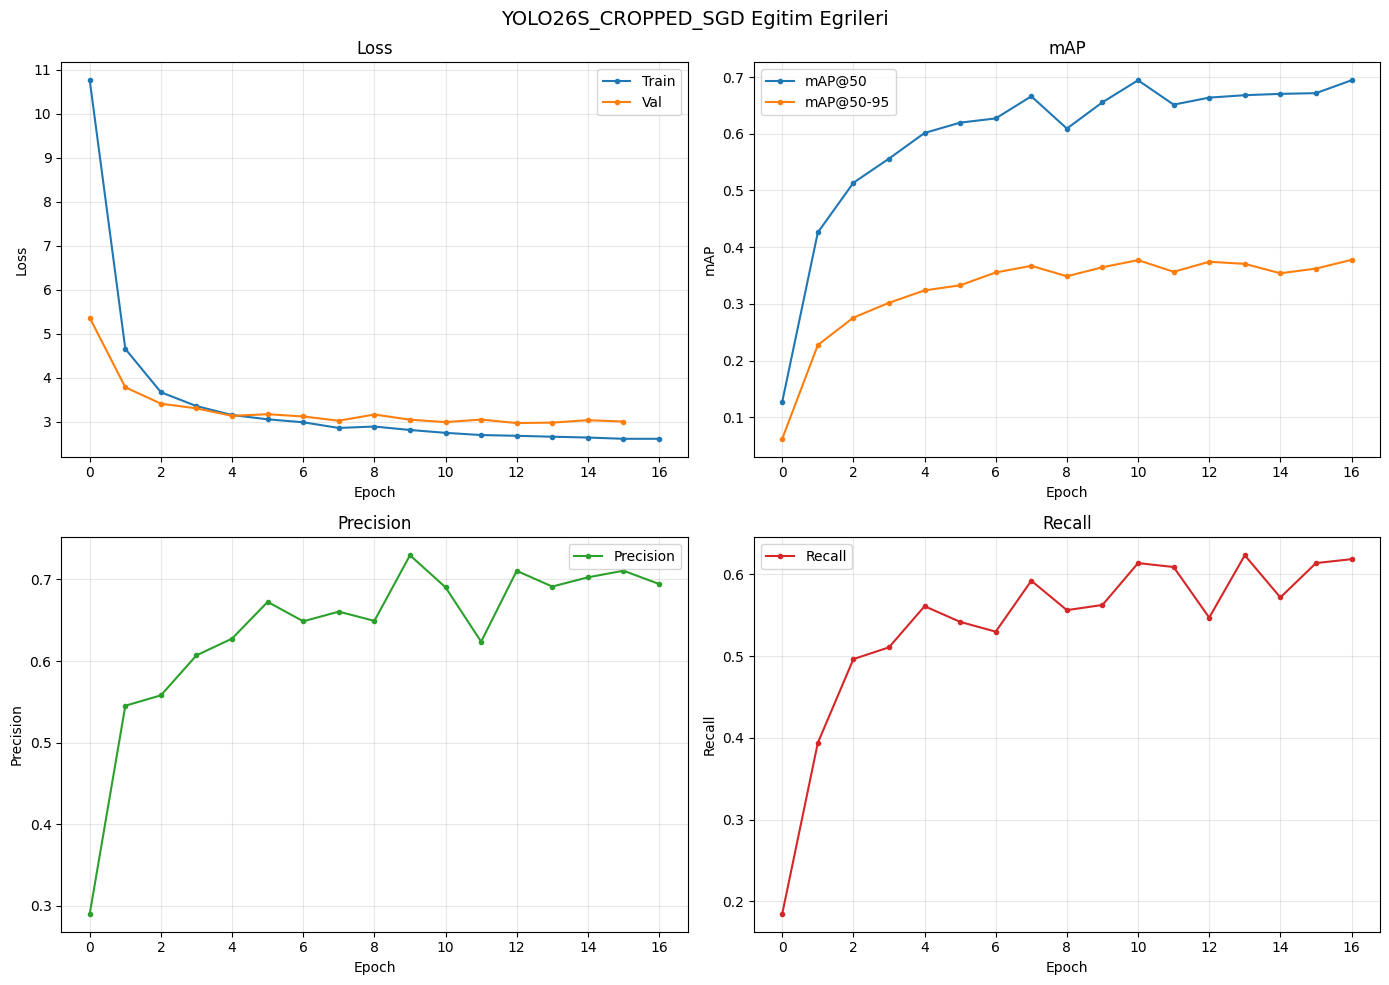

Egitim egrileri kaydedildi (Drive + yerel): /content/drive/MyDrive/mass_detection/yolo26s_cropped_sgd/yolo26s_cropped_sgd_curves.png


In [11]:
curves_path = f'{DRIVE_DIR}/{MODEL_NAME}_curves.png'
plot_training_curves(EXCEL_LOG, curves_path, MODEL_NAME.upper())
mirror_to_local(curves_path)
print('Egitim egrileri kaydedildi (Drive + yerel):', curves_path)


TP=253  FP=90  FN=147


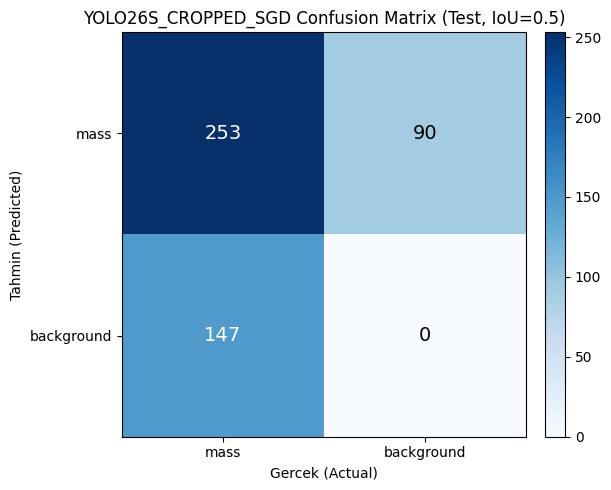

Matristen: Precision=0.738  Recall=0.632
Kaydedildi (Drive + yerel): /content/drive/MyDrive/mass_detection/yolo26s_cropped_sgd/yolo26s_cropped_sgd_confusion_matrix.png


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

BEST_CKPT = f'{DRIVE_DIR}/{MODEL_NAME}_mass/weights/best.pt'
cm_model = YOLO(BEST_CKPT)
TEST_IMG_DIR = Path(DATASET_ROOT) / 'test' / 'images'
TEST_LBL_DIR = Path(DATASET_ROOT) / 'test' / 'labels'


def iou_xywh(b1, b2):
    def corners(b):
        x, y, w, h = b
        return [x-w/2, y-h/2, x+w/2, y+h/2]
    a, b = corners(b1), corners(b2)
    inter = max(0, min(a[2], b[2])-max(a[0], b[0])) * max(0, min(a[3], b[3])-max(a[1], b[1]))
    ua = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter/ua if ua > 0 else 0


def load_gt(stem):
    lp = TEST_LBL_DIR / f'{stem}.txt'
    gts = []
    if lp.exists():
        for line in open(lp):
            parts = line.split()
            if len(parts) >= 5:
                gts.append([float(x) for x in parts[1:5]])
    return gts


TP = FP = FN = 0
IOU_THR = 0.5
CONF_THR = 0.25

all_imgs = sorted(TEST_IMG_DIR.glob('*.png'))
for ip in all_imgs:
    res = cm_model.predict(str(ip), imgsz=1024, conf=CONF_THR, verbose=False)[0]
    preds = []
    if res.boxes is not None and len(res.boxes) > 0:
        preds = [list(b) for b in res.boxes.xywhn.cpu().numpy()]
    gts = load_gt(ip.stem)

    matched = set()
    for pb in preds:
        best, bj = 0, -1
        for j, gb in enumerate(gts):
            if j in matched:
                continue
            i = iou_xywh(pb, gb)
            if i > best:
                best, bj = i, j
        if best >= IOU_THR:
            TP += 1
            matched.add(bj)
        else:
            FP += 1
    FN += len(gts) - len(matched)

print(f'TP={TP}  FP={FP}  FN={FN}')

cm = np.array([[TP, FP],
               [FN, 0]])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

labels = ['mass', 'background']
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Gercek (Actual)')
ax.set_ylabel('Tahmin (Predicted)')
ax.set_title(f'{MODEL_NAME.upper()} Confusion Matrix (Test, IoU={IOU_THR})')

for i in range(2):
    for j in range(2):
        val = cm[i, j]
        color = 'white' if val > cm.max()/2 else 'black'
        ax.text(j, i, str(val), ha='center', va='center', color=color, fontsize=14)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
cm_path = f'{DRIVE_DIR}/{MODEL_NAME}_confusion_matrix.png'
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
mirror_to_local(cm_path)
plt.show()

prec = TP/(TP+FP) if (TP+FP) > 0 else 0
rec = TP/(TP+FN) if (TP+FN) > 0 else 0
print(f'Matristen: Precision={prec:.3f}  Recall={rec:.3f}')
print('Kaydedildi (Drive + yerel):', cm_path)


### Grad-CAM -- mimari notu (teshis edildi)

YOLO11'de hedef katman (layer 16, P3 olcegi) teshis edilerek bulunmustu
(bkz. PROJE_DOKUMANI.md bolum 9). YOLO26 **NMS'siz (end2end)** tasarim
kullaniyor: `Detect` basinda YOLO11'in `cv2`/`cv3` dallari `None`, bunlarin
yerine `one2one_cv2` (kutu regresyonu) ve `one2one_cv3` (sinif logit'i)
var.

Ayrica bir teshis daha gerekti: `one2one_cv3` dali, paylasilan backbone
ozelligini (layer 16) **detach edilmis (stop-gradient)** halde aliyor gibi
gorunuyor -- backward() basariyla calisiyor ama layer 16'nin gradyani hep
`None` geliyordu. Bu yuzden aktivasyon haritasi da hedef katmandan degil,
**`one2one_cv3[0]`'in kendi ilk konvolusyonundan** aliniyor -- boylece
aktivasyon ve gradyan ayni (kopmamis) grafik dalinin icinde kaliyor. Isi
haritasi artik backbone'u degil, siniflandirma dalinin kendi erken
katmanini gosteriyor -- YOLO11'e gore biraz farkli bir yorum, ama gecerli
ve calisan bir Grad-CAM.

Secilen ornek: 9
  Dogru: 058e5f91678b4d3dac39bf1b6a798a22.png
  Dogru: 0734a9dc7d6d89e8c91458545afeef9d.png
  Dogru: 0d0826dc6e633a7729ea56fa7390c508.png
  Dogru: 0dc38f7b2936fff46ec10a0beb5aaeb2.png
  Kacirilan: 00be38a5c0566291168fe381ba0028e6.png
  Kacirilan: 02d253f51556e2e0af63525de2e9ff74.png
  Kacirilan: 032ab9e0ecd5fd673517ffa3eb805d15.png
  Yanlis Alarm: 0c19be554e27e2fdc2fe05ad954e825c.png
  Yanlis Alarm: 11041_RCC.png


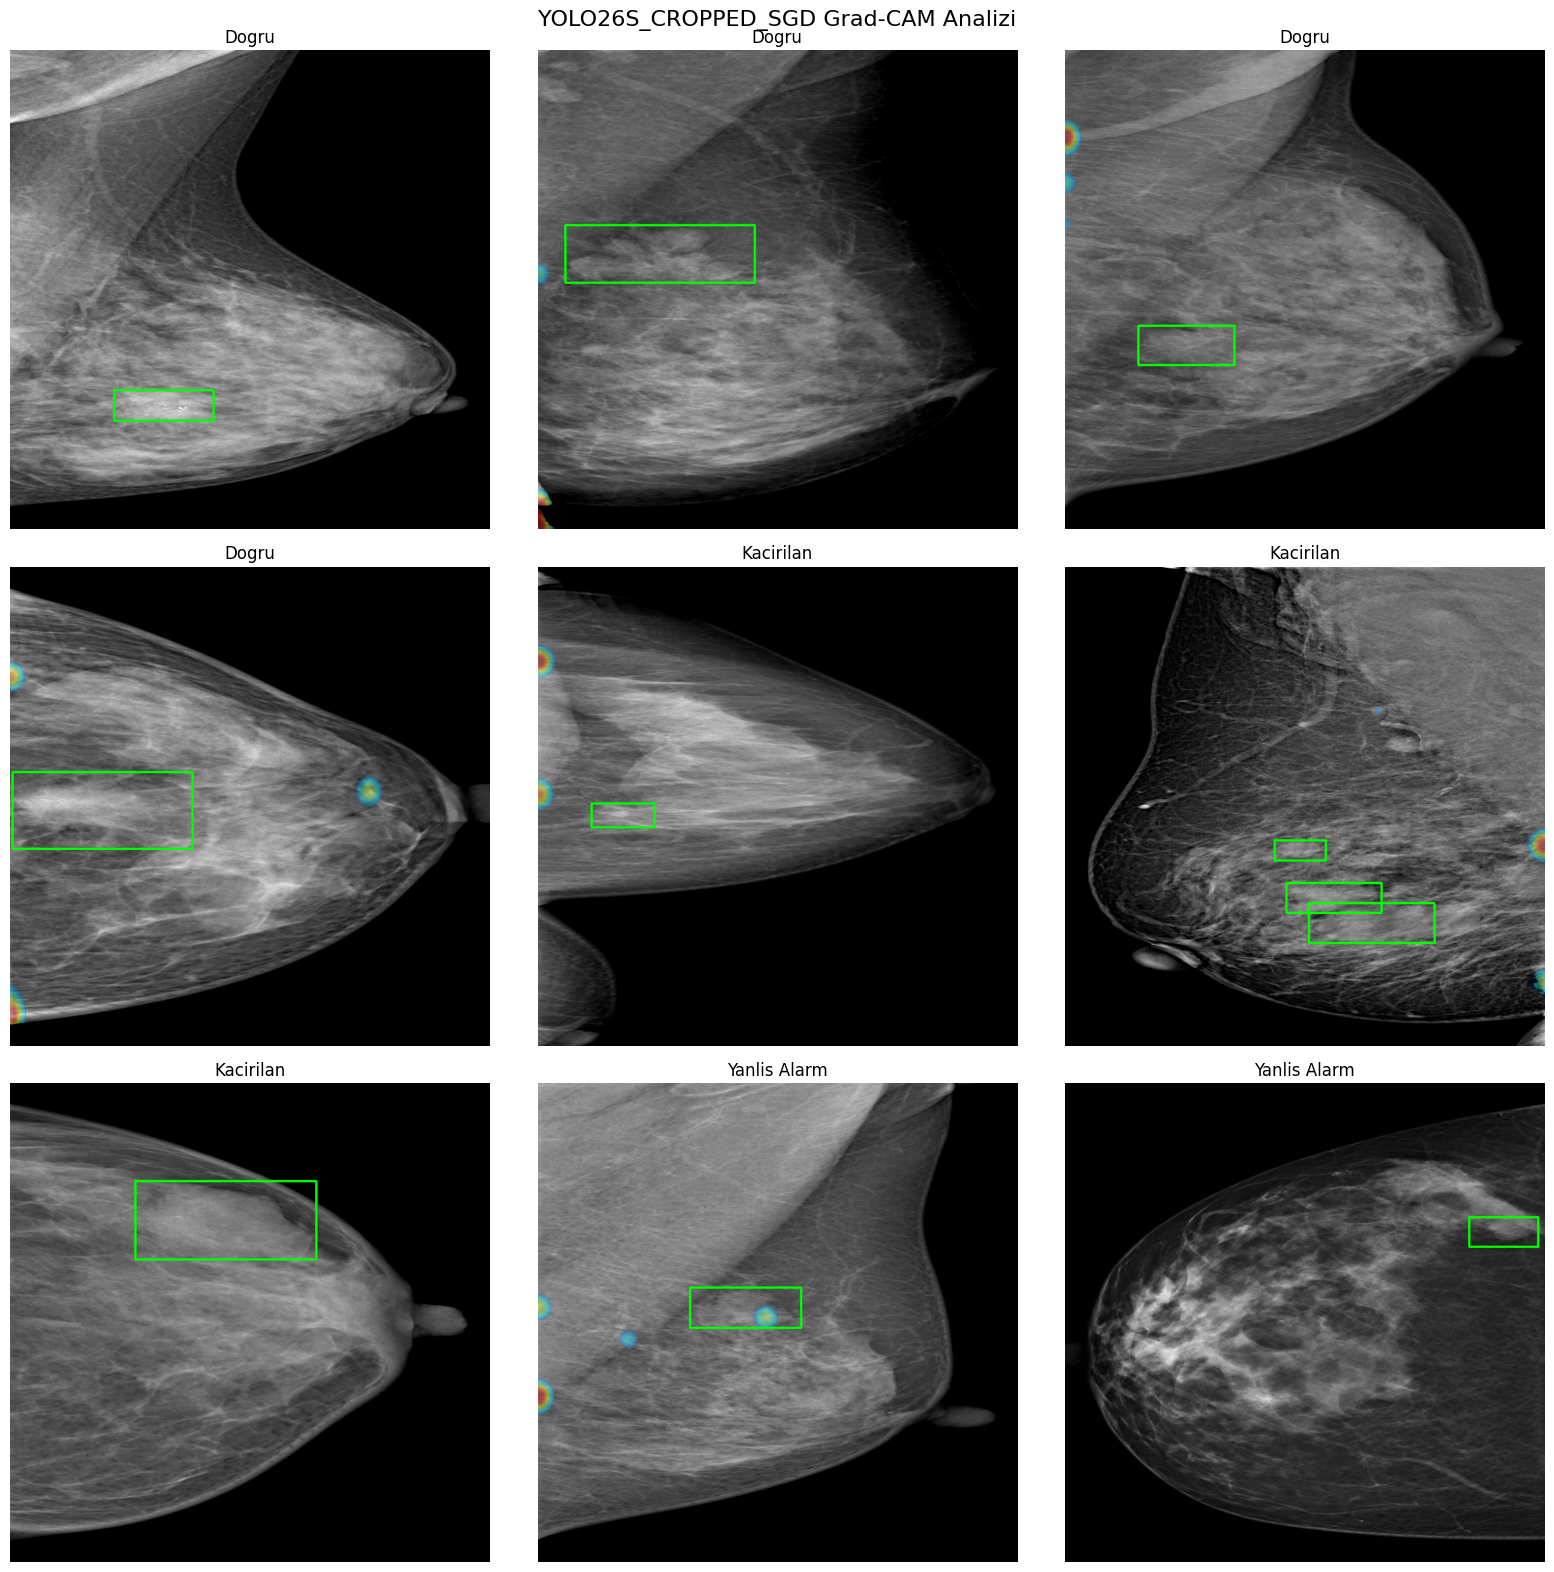

Grad-CAM kaydedildi (Drive + yerel): /content/drive/MyDrive/mass_detection/yolo26s_cropped_sgd/yolo26s_cropped_sgd_gradcam.png


In [13]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

BEST_CKPT = f'{DRIVE_DIR}/{MODEL_NAME}_mass/weights/best.pt'
gc_model = YOLO(BEST_CKPT)  # used only for .predict() (categorize / target selection)

# separate, never-.predict()-ed model instance for the manual backward pass --
# Ultralytics' predict() runs under torch.inference_mode(), which can
# permanently mark cached internal tensors (e.g. anchors/strides) of a
# module as "inference tensors" that can never require grad again, even
# outside that context and even in train() mode. Isolating the two models
# avoids that poisoning.
# manuel geri yayilim icin ayri, hic .predict() cagrilmamis model nesnesi --
# Ultralytics'in predict()'i torch.inference_mode() altinda calisiyor, bu da
# bir modulun ic onbellekteki tensorlerini (orn. anchor/stride) kalici olarak
# "inference tensor" isaretleyebiliyor -- bu tensorler o context disinda ve
# train() modunda bile bir daha gradyan gerektiremez. Iki modeli ayirmak bu
# zehirlenmeyi onluyor.
cam_model = YOLO(BEST_CKPT)
tm = cam_model.model.to(device := ('cuda' if torch.cuda.is_available() else 'cpu'))
tm.eval()
for p in tm.parameters():
    p.requires_grad_(True)

CAM_THRESH = 0.25
CAM_IMGSZ = 1024  # matches Deney 2f training resolution / Deney 2f egitim cozunurlugu
TEST_IMG_DIR = Path(DATASET_ROOT) / 'test' / 'images'
TEST_LBL_DIR = Path(DATASET_ROOT) / 'test' / 'labels'


def iou_xywh(b1, b2):
    def corners(b):
        x, y, w, h = b
        return [x-w/2, y-h/2, x+w/2, y+h/2]
    a, b = corners(b1), corners(b2)
    inter = max(0, min(a[2], b[2])-max(a[0], b[0])) * max(0, min(a[3], b[3])-max(a[1], b[1]))
    ua = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter/ua if ua > 0 else 0


def load_gt(stem):
    lp = TEST_LBL_DIR / f'{stem}.txt'
    gts = []
    if lp.exists():
        for line in open(lp):
            parts = line.split()
            if len(parts) >= 5:
                gts.append([float(x) for x in parts[1:5]])
    return gts


def categorize(img_path):
    res = gc_model.predict(str(img_path), imgsz=CAM_IMGSZ, conf=0.25, verbose=False)[0]
    preds = [list(b) for b in res.boxes.xywhn.cpu().numpy()] if (res.boxes is not None and len(res.boxes) > 0) else []
    gts = load_gt(img_path.stem)
    matched = set(); tp = 0
    for pb in preds:
        best, bj = 0, -1
        for j, gb in enumerate(gts):
            if j in matched:
                continue
            i = iou_xywh(pb, gb)
            if i > best:
                best, bj = i, j
        if best >= 0.5:
            tp += 1; matched.add(bj)
    fp = len(preds) - tp
    fn = len(gts) - len(matched)
    if tp > 0 and fp == 0 and fn == 0:
        return 'dogru'
    elif fp > 0 and tp == 0:
        return 'yanlis_alarm'
    elif fn > 0 and tp == 0:
        return 'kacirilan'
    return 'karisik'

def compute_overlay(img_path):
    # activation + logit both come from inside one2one_cv3[0] itself --
    # YOLO26's end2end head appears to feed the one2one branch a
    # detached (stop-gradient) copy of the shared P3 backbone feature
    # (layer 16): gradient reached the logit fine but never reached
    # layer 16's activation. So both hooks live inside the same branch,
    # guaranteeing graph connectivity: activation = first conv of
    # one2one_cv3[0], logit = last conv of the same Sequential.
    # aktivasyon + logit ikisi de one2one_cv3[0]'in kendi icinden --
    # YOLO26'nin end2end basi one2one dalina paylasilan P3 backbone
    # ozelliginin (layer 16) detach edilmis (stop-gradient) bir kopyasini
    # besliyor gibi gorunuyor: gradyan logit'e ulasti ama layer 16'nin
    # aktivasyonuna hic ulasmadi. Bu yuzden iki hook da ayni dalin icinde:
    # aktivasyon = one2one_cv3[0]'in ilk konvolusyonu, logit = ayni
    # Sequential'in son konvolusyonu.
    tm.to(device)

    # target selection still uses gc_model.predict() (the "poisoned" model,
    # fine since we never backprop through it)
    # hedef secimi hala gc_model.predict() kullaniyor ("zehirlenmis" model,
    # sorun degil cunku ondan hic geri yayilim yapmiyoruz
    res = gc_model.predict(str(img_path), imgsz=CAM_IMGSZ, conf=0.25, verbose=False)[0]
    det_boxes = res.boxes.xywhn.cpu().numpy() if (res.boxes is not None and len(res.boxes) > 0) else []
    gts = load_gt(img_path.stem)

    if len(det_boxes) > 0:
        confs = res.boxes.conf.cpu().numpy()
        bx = det_boxes[confs.argmax()]
        target_cx, target_cy = float(bx[0]), float(bx[1])
    elif len(gts) > 0:
        target_cx, target_cy = gts[0][0], gts[0][1]
    else:
        target_cx, target_cy = 0.5, 0.5

    img_bgr = cv2.imread(str(img_path))
    img_r = cv2.resize(img_bgr, (CAM_IMGSZ, CAM_IMGSZ))
    x = torch.from_numpy(img_r[:, :, ::-1].copy()).permute(2, 0, 1).float() / 255.0
    x = x.unsqueeze(0).to(device)
    x.requires_grad_(True)

    cls_branch = tm.model[-1].one2one_cv3[0]

    cam_store = {}
    def cam_hook(m, i, o):
        o.retain_grad()
        cam_store['out'] = o
    h_cam = cls_branch[0].register_forward_hook(cam_hook)
    logit_store = {}
    def logit_hook(m, i, o):
        logit_store['out'] = o
    h_logit = cls_branch.register_forward_hook(logit_hook)

    with torch.enable_grad():
        tm.zero_grad()
        _ = tm(x)
        logits = logit_store['out']
        _, nc, Hh, Ww = logits.shape
        gx = min(int(target_cx * Ww), Ww - 1)
        gy = min(int(target_cy * Hh), Hh - 1)
        target = logits[0, :, gy, gx].sum()
        target.backward()

    A = cam_store['out'].detach()
    G = cam_store['out'].grad
    w = G.mean(dim=[2, 3], keepdim=True)
    cam = torch.relu((w * A).sum(dim=1)).squeeze().cpu().numpy()
    if cam.max() > cam.min():
        cam = (cam - cam.min()) / (cam.max() - cam.min())
    h_cam.remove()
    h_logit.remove()

    cam_r = cv2.resize(cam.astype('float32'), (CAM_IMGSZ, CAM_IMGSZ))
    cam_r = cv2.GaussianBlur(cam_r, (0, 0), sigmaX=20)
    if cam_r.max() > 0:
        cam_r = cam_r / cam_r.max()

    gray = cv2.cvtColor(img_r, cv2.COLOR_BGR2GRAY)
    tissue = (gray > 15).astype('float32')
    cam_r = cam_r * tissue

    hm = cv2.applyColorMap(np.uint8(255 * cam_r), cv2.COLORMAP_JET)
    blended = cv2.addWeighted(img_r, 0.6, hm, 0.4, 0)
    mask = (cam_r >= CAM_THRESH)[:, :, None]
    overlay = np.where(mask, blended, img_r).astype(np.uint8)

    for (cx, cy, bw, bh) in gts:
        x1 = int((cx - bw/2) * CAM_IMGSZ)
        y1 = int((cy - bh/2) * CAM_IMGSZ)
        x2 = int((cx + bw/2) * CAM_IMGSZ)
        y2 = int((cy + bh/2) * CAM_IMGSZ)
        cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 255, 0), 3)

    return overlay

all_imgs = sorted(TEST_IMG_DIR.glob('*.png'))
buckets = {'dogru': [], 'kacirilan': [], 'yanlis_alarm': [], 'karisik': []}
for ip in all_imgs[:120]:
    buckets[categorize(ip)].append(ip)

selected = []
selected += [(p, 'Dogru') for p in buckets['dogru'][:4]]
selected += [(p, 'Kacirilan') for p in buckets['kacirilan'][:3]]
selected += [(p, 'Yanlis Alarm') for p in buckets['yanlis_alarm'][:2]]
while len(selected) < 9 and buckets['karisik']:
    selected.append((buckets['karisik'].pop(0), 'Karisik'))
selected = selected[:9]

print(f'Secilen ornek: {len(selected)}')
for p, lab in selected:
    print(f'  {lab}: {p.name}')

fig, axes = plt.subplots(3, 3, figsize=(16, 16))
for ax, (ip, lab) in zip(axes.flat, selected):
    ov = compute_overlay(ip)
    ax.imshow(cv2.cvtColor(ov, cv2.COLOR_BGR2RGB))
    ax.set_title(lab, fontsize=12)
    ax.axis('off')
for ax in axes.flat[len(selected):]:
    ax.axis('off')

plt.suptitle(f'{MODEL_NAME.upper()} Grad-CAM Analizi', fontsize=16)
plt.tight_layout()
gradcam_path = f'{DRIVE_DIR}/{MODEL_NAME}_gradcam.png'
plt.savefig(gradcam_path, dpi=150, bbox_inches='tight')
mirror_to_local(gradcam_path)
plt.show()
print('Grad-CAM kaydedildi (Drive + yerel):', gradcam_path)
